# Assignment 1 Part 1

## Part 1a
- Random number in range [0,1]                       : Discrete
- Number of bike stores in Groningen                 : Discrete
- Handedness                                         : Categorical
- Current types of Machine Learning methods.         : Categorical
- Duration of your trip from home to campus Zernike. : Continuous

## Part 1b
Features:
1. Number of coffee units drunk per day.
2. Number of study hours.
3. Number of sleeping hours.
4. Country where a student obtained their high school diploma.
5. Age.
6. Number of times the student attended lectures.

Answer these two questions, considering the problem of individual student success rate.
1. Which of these features is/are useful to predict the success rate of students passing a course?
Please explain your choice.
    - 2, 3, 4, 6
    - 2: If the student studies more, they tend to do better
    - 3: Need sleep to function
    - 4: Dictates base knowledge, might need to study more to compensate
    - 6: Shows commitment to the course and discipline to study

2. Is predicting the success rate of students passing a course a classification or a regression task?
Please explain your reasoning.
    - Regression.
    - This is more of a prediction task, where we are forecasting the chance a student will do well in the course. 

## Part 1c

In [360]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# as_frame=True returns the 8 features and the target already joined in one DataFrame.
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [362]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [363]:
# Choosing features and target variable
features_housing = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']
x_all = df.drop(columns=['MedHouseVal'])
x_housing = df[features_housing]
y_housing = df['MedHouseVal']

In [364]:
# Linear regression with selected features

x_train, x_test, y_train, y_test = train_test_split(x_housing, y_housing, test_size = 0.2, random_state = 42)

# Normalize the features using minmax scaling
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) 

model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

print("selected features, R2 =", r2_score(y_test, predictions))
for name, coef in zip(features_housing, model.coef_):
    print(name, round(coef, 3))

selected features, R2 = 0.5089947802907757
MedInc 7.902
HouseAge 0.847
AveRooms -31.45
AveBedrms 28.098
Population 0.684


Explanation:
- The selected features produced a R2 score of 0.509 (3sf).
- This suggests that the selected features contain useful information for predicting house prices, although a substantial amount of variation remains unexplained.
- Therefore, the R2 score is not sufficient to determine whether the relationship between the features and target is truly linear. 

In [365]:
# Linear regression with all features

x_train2, x_test2, y_train2, y_test2 = train_test_split(x_all, y_housing, test_size = 0.2, random_state = 42)

model_all = LinearRegression()
model_all.fit(x_train2, y_train2)
predictions_all = model_all.predict(x_test2)

print("all features, R2 =", r2_score(y_test2, predictions_all))

all features, R2 = 0.5757877060324517


Comparison of R2 of selected features and all features:
- The model using all features achieved a R2 score of 0.576 (3sf), compared with 0.509 for the selected features.
- The higher R2 score indicates that the additional features provided useful predictive information that was not captured by the selected features alone.

In [366]:
# Single transformation of selected features

x_new = x_housing.copy()
x_new['MedInc'] = np.log(x_new['MedInc'])
x_new['HouseAge'] = np.sqrt(x_new['HouseAge'])
x_new['AveRooms'] = np.log(x_new['AveRooms'])
x_new['AveBedrms'] = np.log(x_new['AveBedrms'])
x_new['Population'] = np.log(x_new['Population'])

In [367]:
# Linear regression with transformed features

x_train3, x_test3, y_train3, y_test3 = train_test_split(x_new, y_housing, test_size = 0.2, random_state = 42)

model_new = LinearRegression()
model_new.fit(x_train3, y_train3)
predictions_new = model_new.predict(x_test3)

print("transformed features, R2 =", r2_score(y_test3, predictions_new))

transformed features, R2 = 0.48625396966876966


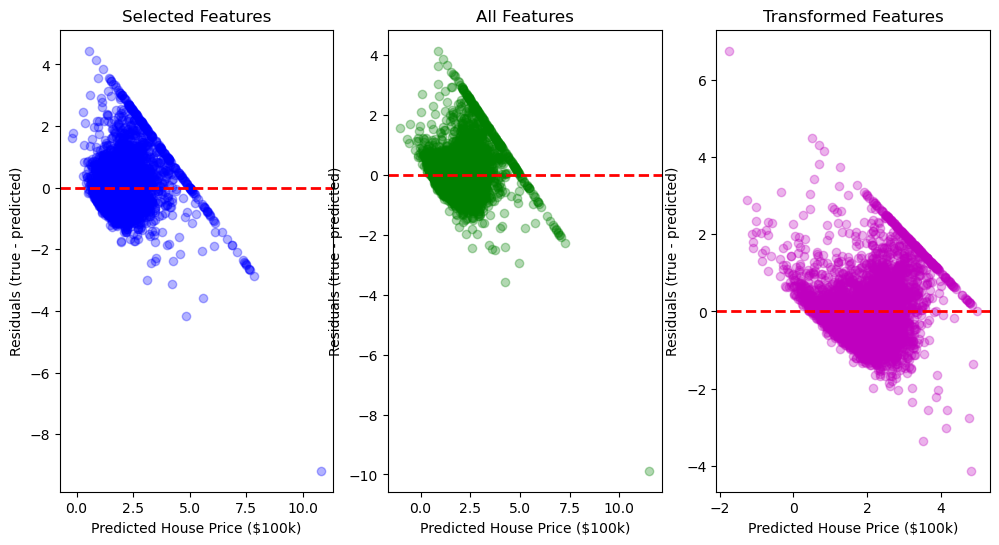

In [368]:
# Residual plots

residuals = y_test - predictions
residuals_all = y_test2 - predictions_all
residuals_new = y_test3 - predictions_new

plots = [(predictions, residuals, 'b', "Selected Features"),
         (predictions_all, residuals_all, 'g', "All Features"),
         (predictions_new, residuals_new, 'm', "Transformed Features")]

plt.figure(figsize = (12,6))
for i, (pred, res, color, title) in enumerate(plots, start = 1):
    plt.subplot(1, 3, i)
    plt.scatter(pred, res, color = color, alpha = 0.3)
    plt.axhline(y = 0, color = 'r', linestyle = '--', linewidth = 2)
    plt.xlabel('Predicted House Price ($100k)')
    plt.ylabel('Residuals (true - predicted)')
    plt.title(title)

Evaluation:
- The three residual plots show a similar pattern: rather than scattering randomly around the y = 0 line, the residuals form a downward-sloping trend in all three cases (selected, all, and transformed features).
- This indicates that even after transformation, the model is over-predicting at higher predicted prices and under-predicting at lower ones. 
- The transformed features achieved a R2 score of 0.486 (3sf), which is lower than the untransformed selected features model's R2 score of 0.509 (3sf), suggesting that this particular transformation did not improve the linear fit.
- Perhaps a different transformation or feature may better linearize the relationship.

In [369]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame

print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [370]:
import pandas as pd
import numpy as np
import sklearn

print("Everything works!")

Everything works!
